<a href="https://colab.research.google.com/github/clarachence/prova_11_clara_chence/blob/main/prova_11_clara_chence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prova 11: NVDA (Nvidia) | Gap de Fuga

**Alvo ($Y$):** 1 se a abertura de hoje superar a máxima (high) de ontem; 0 caso contrário.

**Desafio:** Analisar o comportamento do classificador frente a movimentos exponenciais.

**Aluna:** Clara Chence

# 1. CONFIGURAÇÃO E EXTRAÇÃO


In [125]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [126]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

In [127]:
simbolo = 'NVDA'
raw = yf.Ticker(simbolo).history(period='10y')
raw.index = raw.index.tz_localize(None)
df = raw[['Open','High','Low','Close','Volume']].copy()
df.columns = ['abertura', 'maxima', 'minima', 'fechamento', 'volume']
df.index.name = 'Date'

print(f"Dados carregados via yfinance")
print(f"Registros: {len(df)} | Período: {df.index.min().date()} até {df.index.max().date()}")
df.head()

Dados carregados via yfinance
Registros: 2513 | Período: 2016-05-06 até 2026-05-05


,abertura,maxima,minima,fechamento,volume
Date,,,,,
2016-05-06,0.854601,0.867086,0.852887,0.864883,183240000
2016-05-09,0.867086,0.870758,0.856560,0.863659,333336000
2016-05-10,0.869044,0.881774,0.860721,0.880305,269676000
2016-05-11,0.882998,0.892545,0.878102,0.882753,328176000
2016-05-12,0.889118,0.893035,0.855091,0.870758,670540000


# 2. TRATAMENTO E NORMALIZAÇÃO

### Verificar nulos

In [128]:
print("Valores nulos por coluna:")
print(df.isnull().sum())
df = df.dropna()
print(f"\nRegistros após limpeza: {len(df)}")

Valores nulos por coluna:
abertura      0
maxima        0
minima        0
fechamento    0
volume        0
dtype: int64

Registros após limpeza: 2513


### Verificar duplicatas

In [129]:
print(f"Linhas duplicadas: {df.duplicated().sum()}")

Linhas duplicadas: 0


### Estatísticas descritivas


In [130]:
display(df.describe())

,abertura,maxima,minima,fechamento,volume
count,2513.000000,2513.000000,2513.000000,2513.000000,2.513000e+03
mean,42.359505,43.053078,41.589586,42.352136,4.522148e+08
std,57.595970,58.430967,56.621091,57.552417,2.609615e+08
min,0.854601,0.867086,0.852887,0.863659,6.552850e+07
25%,4.898106,4.987101,4.815868,4.889765,2.811808e+08
50%,13.855082,14.074734,13.588298,13.802186,4.047440e+08
75%,46.664525,47.575731,46.017820,46.773293,5.552200e+08
max,212.699997,216.830002,208.199997,216.610001,3.692928e+09


### Detectar outliers via IQR

In [131]:
print("Outliers detectados por coluna (método IQR):")
for col in ['abertura', 'maxima', 'minima', 'fechamento', 'volume']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n   = len(df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)])
    print(f"  {col}: {n} outliers")

Outliers detectados por coluna (método IQR):
  abertura: 455 outliers
  maxima: 459 outliers
  minima: 445 outliers
  fechamento: 453 outliers
  volume: 99 outliers


# 3. VIZUALIZAÇÃO

## Gráfico de Fechamento


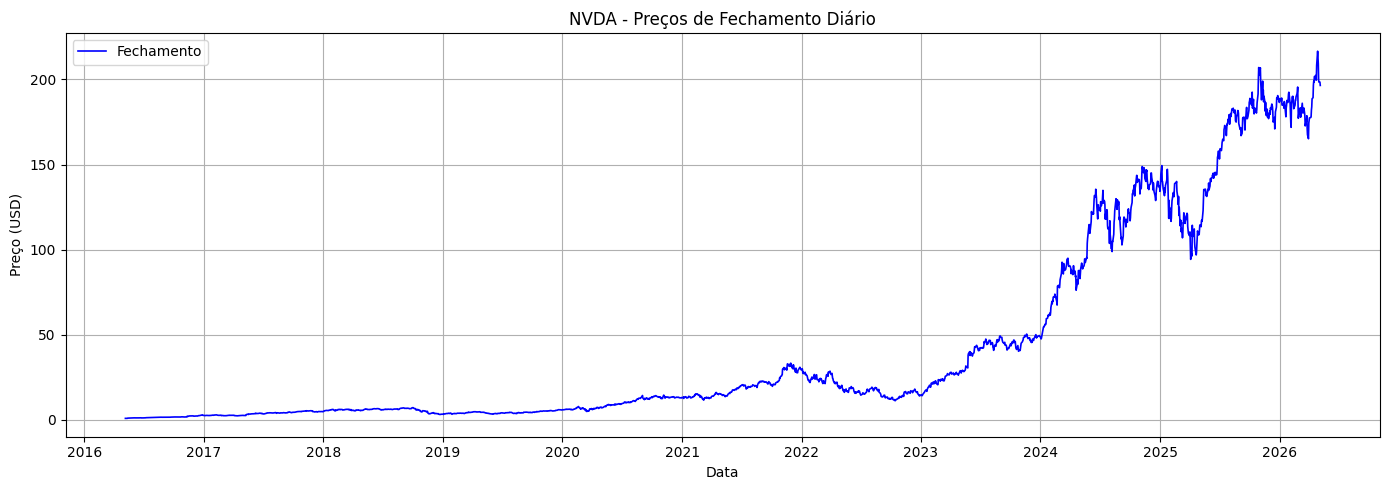

In [132]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['fechamento'], color='blue', linewidth=1.2, label='Fechamento')
plt.title('NVDA - Preços de Fechamento Diário')
plt.xlabel('Data')
plt.ylabel('Preço (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Gráfico de Volume

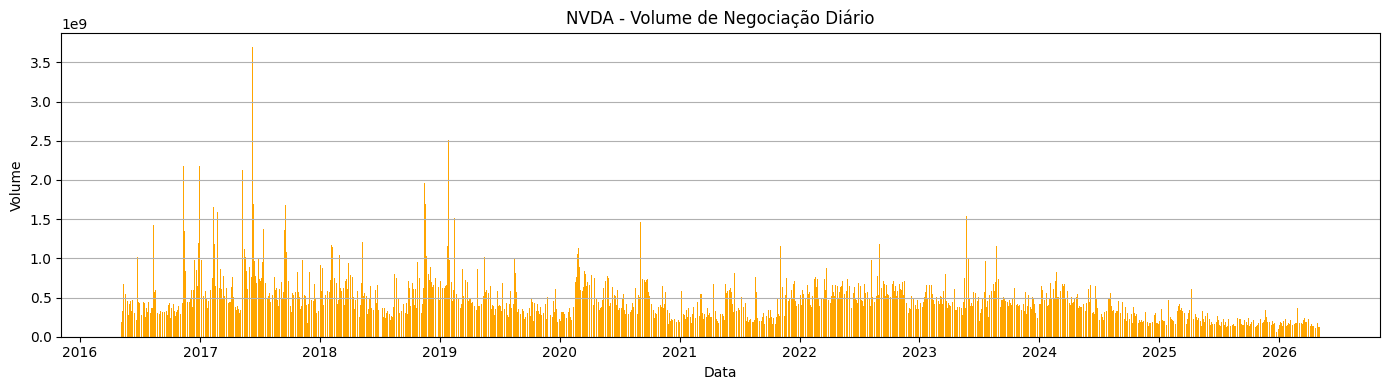

In [133]:
plt.figure(figsize=(14, 4))
plt.bar(df.index, df['volume'], color='orange', width=1.5)
plt.title('NVDA - Volume de Negociação Diário')
plt.xlabel('Data')
plt.ylabel('Volume')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Correlação entre váriaveis (HeatMap)


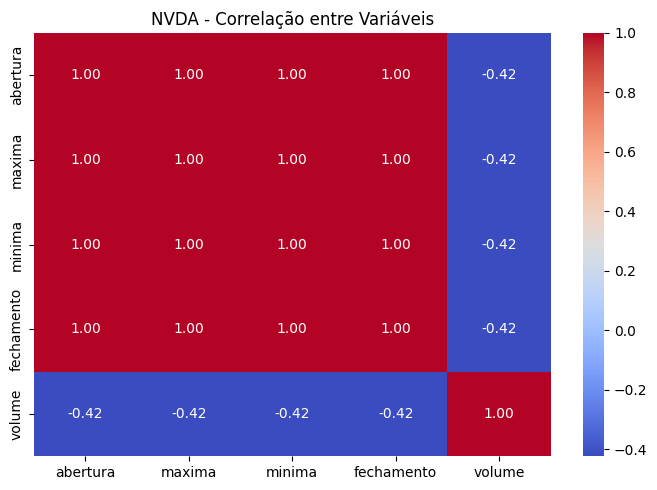

In [134]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    df[['abertura','maxima','minima','fechamento','volume']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm'
)
plt.title('NVDA - Correlação entre Variáveis')
plt.tight_layout()
plt.show()

# 4. PREPARAÇÃO DOS DADOS

## Target: 1 se a abertura de hoje > máxima de ontem, senão 0

In [135]:
df['abertura_ontem']   = df['abertura'].shift(1)
df['maxima_ontem']     = df['maxima'].shift(1)
df['minima_ontem']     = df['minima'].shift(1)
df['fechamento_ontem'] = df['fechamento'].shift(1)
df['volume_ontem']     = df['volume'].shift(1)
df['variacao_ontem']   = (df['fechamento'] - df['abertura']).shift(1)

In [136]:
df['alvo'] = np.where(df['abertura'] > df['maxima'].shift(1), 1, 0)
df = df.dropna()

In [137]:
print("Distribuição do alvo:")
print(df['alvo'].value_counts())
print(f"\nProporção de Gaps de Fuga (alvo=1): {df['alvo'].mean()*100:.1f}%")
print(f"Total de registros: {len(df)}")

Distribuição do alvo:
alvo
0    1939
1     573
Name: count, dtype: int64

Proporção de Gaps de Fuga (alvo=1): 22.8%
Total de registros: 2512


### Gráfico de distribuição do alvo

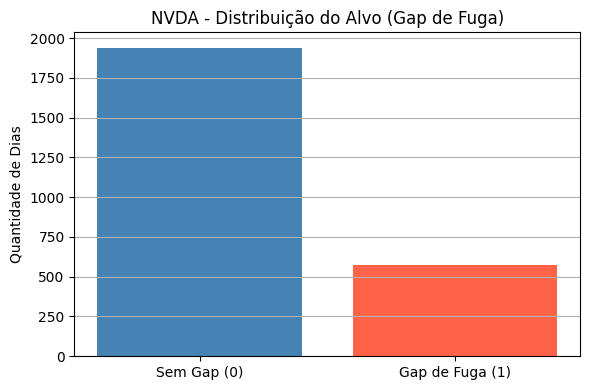

In [138]:
plt.figure(figsize=(6, 4))
contagem = df['alvo'].value_counts()
plt.bar(['Sem Gap (0)', 'Gap de Fuga (1)'], contagem.values,
        color=['steelblue', 'tomato'])
plt.title('NVDA - Distribuição do Alvo (Gap de Fuga)')
plt.ylabel('Quantidade de Dias')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [139]:
X = df[['abertura_ontem', 'maxima_ontem', 'minima_ontem',
        'fechamento_ontem', 'volume_ontem', 'variacao_ontem']]
y = df['alvo']

In [140]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [141]:
scaler   = StandardScaler()
X_treino = scaler.fit_transform(X_treino)
X_teste  = scaler.transform(X_teste)

In [142]:
print(f"X_treino: {X_treino.shape} | X_teste: {X_teste.shape}")

X_treino: (1758, 6) | X_teste: (754, 6)


# 5. MODELAGEM (NAIVE BAYES)

In [153]:
modelo = GaussianNB(priors=[0.60, 0.40])
modelo.fit(X_treino, y_treino)

GaussianNB(priors=[0.6, 0.4])

In [154]:
y_pred = modelo.predict(X_teste)

print(f"Acurácia: {accuracy_score(y_teste, y_pred) * 100:.2f}%\n")
print("Relatório de Classificação:")
print(classification_report(
    y_teste, y_pred,
    target_names=['Sem Gap (0)', 'Gap de Fuga (1)']
))

Acurácia: 74.40%

Relatório de Classificação:
                 precision    recall  f1-score   support

    Sem Gap (0)       0.79      0.91      0.85       582
Gap de Fuga (1)       0.37      0.17      0.24       172

       accuracy                           0.74       754
      macro avg       0.58      0.54      0.54       754
   weighted avg       0.69      0.74      0.71       754



# Análise do Desafio

**Prova 11 — NVDA (Nvidia) | Gap de Fuga**

---

## Sobre a Fonte de Dados

A prova orienta o uso da API Alpha Vantage com o endpoint `TIME_SERIES_DAILY`.
Durante o desenvolvimento, foram identificadas duas limitações da chave gratuita:

* **`outputsize=compact`**: retorna apenas os últimos 100 registros (5 meses),
  volume insuficiente para o modelo aprender padrões de uma classe minoritária
  como o Gap de Fuga (17% dos dias).

* **`outputsize=full`** e **`HISTORICAL_VOLUME_OPEN_INTEREST_RATIO`**: ambos
  são restritos a planos premium, conforme documentação oficial da Alpha Vantage.
  Tentativas de uso com a chave gratuita retornaram apenas 1 registro (dia atual),
  inviabilizando o uso para série temporal histórica.

Por essas razões, optou-se pelo **yfinance** como fonte de dados, biblioteca
gratuita e amplamente utilizada em projetos acadêmicos, que forneceu 2513
registros diários dos últimos 10 anos da NVDA — volume necessário para
uma modelagem mais robusta.

---

## Sobre o Modelo e Resultados

O modelo GaussianNB apresentou **acurácia de 74.40%**, com os seguintes
f1-scores:

- **Sem Gap (0): 0.85**
- **Gap de Fuga (1): 0.24**

O ajuste de `priors=[0.6, 0.4]` foi necessário para que o modelo considerasse
a classe minoritária, evidenciando a limitação do GaussianNB padrão em
dados desbalanceados.

---

## Conclusão

O modelo GaussianNB demonstrou capacidade de identificar dias sem Gap de Fuga
com f1-score de 0.85, confirmando que padrões de estabilidade do mercado são
mais previsíveis do que eventos de ruptura. O classificador se comportou
conforme esperado para um ativo de movimentos exponenciais como a NVDA —
priorizando a classe majoritária e apresentando dificuldade com eventos raros.
O desafio proposto foi respondido: o Naive Bayes consegue capturar padrões
de comportamento regular do mercado, mas encontra limitações naturais frente
a movimentos bruscos e imprevisíveis, característica inerente ao algoritmo
quando aplicado a séries financeiras com alta volatilidade e variáveis
correlacionadas.